## Introduction 

In this script, the local closeness per ward is computed and this for the drivable roads only.

## Reading in the Python libraries

In [2]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [6]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [7]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [8]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [9]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 200 wards in the dataset.


Reading in the entire Chennai network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [10]:
G = ox.io.load_graphml(path_graphml)

In [11]:
G.graph["crs"]

'epsg:4326'

In [12]:
df.crs.to_epsg()

4326

## Computing (local) closeness at the ward level

In [16]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'closeness_local'])
results

,Name,zone_id,zone_name,closeness_local


In [17]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, radius = 500, name='closeness_500', distance='mm_len', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_500'].mean()

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        closeness_mean
    ]
    

Processing wards:   0%|                                                                                                                                                                   | 0/200 [00:00<?, ?it/s]

  0%|          | 0/547 [00:00<?, ?it/s]

Processing wards:   0%|▊                                                                                                                                                          | 1/200 [00:05<19:26,  5.86s/it]

  0%|          | 0/333 [00:00<?, ?it/s]

Processing wards:   1%|█▌                                                                                                                                                         | 2/200 [00:09<15:27,  4.69s/it]

...

Processing wards:  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 198/200 [14:09<00:07,  3.67s/it]

  0%|          | 0/580 [00:00<?, ?it/s]

Processing wards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 199/200 [14:14<00:03,  3.94s/it]

  0%|          | 0/485 [00:00<?, ?it/s]

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [14:22<00:00,  4.31s/it]


In [18]:
results

,Name,zone_id,zone_name,closeness_local
0,168,13,Adyar,0.000387
1,169,13,Adyar,0.000424
2,170,13,Adyar,0.000478
3,171,13,Adyar,0.000480
4,174,13,Adyar,0.000448
...,...,...,...,...
195,110,9,Teynampet,0.000478
196,161,12,Alandur,0.000828
197,160,12,Alandur,0.001373
198,195,15,Sholinganallur,0.000354


In [19]:
top10_highest = (
    results
    .sort_values(by='closeness_local', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,closeness_local
129,51,5,Royapuram,0.001873
166,13,1,Thiruvottyur,0.001840
85,159,12,Alandur,0.001838
167,14,1,Thiruvottyur,0.001788
103,72,6,Thiru-Vi-Ka. Nagar,0.001730
95,77,6,Thiru-Vi-Ka. Nagar,0.001703
120,55,5,Royapuram,0.001682
163,8,1,Thiruvottyur,0.001637
65,20,2,Manali,0.001581
148,48,4,Tondiarpet,0.001551


In [20]:
top10_lowest = (
    results
    .sort_values(by='closeness_local', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,closeness_local
71,83,7,Ambattur,0.000175
19,197,15,Sholinganallur,0.000215
177,32,3,Madhavaram,0.000218
70,82,7,Ambattur,0.000225
15,199,15,Sholinganallur,0.000229
74,86,7,Ambattur,0.000238
18,194,15,Sholinganallur,0.000242
25,189,14,Perungudi,0.000250
184,188,14,Perungudi,0.000268
139,127,10,Kodambakkam,0.000280


In [21]:
print(f'The mean of the local closeness across the wards is {results["closeness_local"].mean()}.')
print(f'The minimum of the local closeness across the wards is {results["closeness_local"].min()}.')
print(f'The maximum of the local closeness across the wards is {results["closeness_local"].max()}.')

The mean of the local closeness across the wards is 0.0007485753582655818.
The minimum of the local closeness across the wards is 0.00017501737184622435.
The maximum of the local closeness across the wards is 0.00187327433180407.


In [22]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_local_closeness_all_roads_drive.csv"

results.to_csv(results_path)

In [23]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_chennai_local_closeness_all_roads_drive.csv"
results = pd.read_csv(results_path)

In [24]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,Name,zone_id,zone_name,closeness_local
0,0,168,13,Adyar,0.000387
1,1,169,13,Adyar,0.000424
2,2,170,13,Adyar,0.000478
3,3,171,13,Adyar,0.000480
4,4,174,13,Adyar,0.000448
...,...,...,...,...,...
195,195,110,9,Teynampet,0.000478
196,196,161,12,Alandur,0.000828
197,197,160,12,Alandur,0.001373
198,198,195,15,Sholinganallur,0.000354


In [25]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,Unnamed: 0,zone_id_y,zone_name_y,closeness_local
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0,13,Adyar,0.000387
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",1,13,Adyar,0.000424
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",2,13,Adyar,0.000478
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",3,13,Adyar,0.000480
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",4,13,Adyar,0.000448
...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",195,9,Teynampet,0.000478
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",196,12,Alandur,0.000828
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",197,12,Alandur,0.001373
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",198,15,Sholinganallur,0.000354


In [26]:
df_merged = df_merged[['Name','zone_id_x', 'zone_name_x', 'geometry', 'closeness_local']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,closeness_local
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0.000387
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",0.000424
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",0.000478
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",0.000480
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",0.000448
...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",0.000478
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",0.000828
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",0.001373
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",0.000354


In [27]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

## Plots

Plot the local closeness at the wards:

In [28]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_local_all_roads_chennai_drive.png'

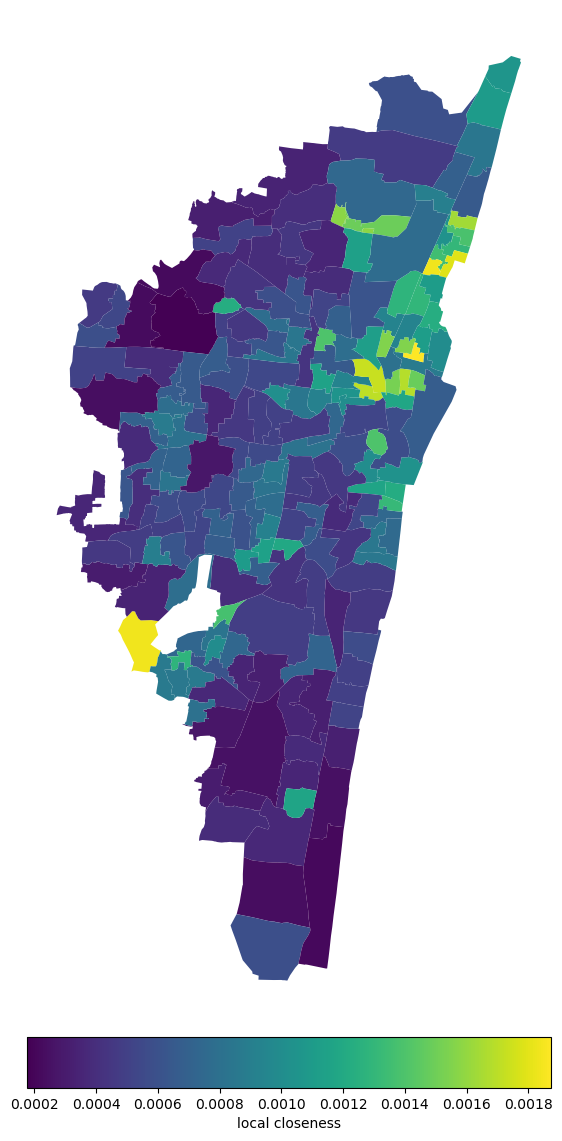

In [29]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness_local",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "local closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()